In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load the cleaned data
df = pd.read_csv('data/insurance_data_cleaned.csv')

print("="*60)
print("HYPOTHESIS TESTING FOR RISK DRIVERS")
print("="*60)
print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

HYPOTHESIS TESTING FOR RISK DRIVERS
Dataset shape: (10000, 25)
Columns: ['CustomerID', 'Age', 'Gender', 'Province', 'VehicleType', 'AnnualIncome', 'RiskScore', 'AnnualPremium', 'Deductible', 'NCD', 'PastClaims', 'Claimed', 'ClaimAmount', 'TotalPremium', 'TotalClaims', 'CoverType', 'AutoMake', 'VehicleModel', 'CustomValueEstimate', 'ZipCode', 'TransactionDate', 'Loss_Ratio', 'Margin', 'YearMonth', 'AgeGroup']


In [2]:
print("="*60)
print("HYPOTHESIS 1: Risk Differences Across Provinces")
print("="*60)

# Group Loss Ratio by Province
province_groups = [df[df['Province'] == p]['Loss_Ratio'].dropna() for p in df['Province'].unique()]

# Perform ANOVA test (compares multiple groups)
f_stat, p_value = stats.f_oneway(*province_groups)

print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.6f}")

alpha = 0.05
if p_value < alpha:
    print(f"\n✅ REJECT Null Hypothesis (p = {p_value:.6f} < {alpha})")
    print("Conclusion: There ARE significant risk differences across provinces.")
    
    # Show which province has highest risk
    province_risk = df.groupby('Province')['Loss_Ratio'].mean().sort_values(ascending=False)
    print(f"\nHighest risk province: {province_risk.index[0]} (Loss Ratio: {province_risk.iloc[0]:.4f})")
    print(f"Lowest risk province: {province_risk.index[-1]} (Loss Ratio: {province_risk.iloc[-1]:.4f})")
else:
    print(f"\n❌ FAIL to reject Null Hypothesis (p = {p_value:.6f} >= {alpha})")
    print("Conclusion: No significant risk differences across provinces.")

HYPOTHESIS 1: Risk Differences Across Provinces
F-statistic: 1.9925
P-value: 0.092767

❌ FAIL to reject Null Hypothesis (p = 0.092767 >= 0.05)
Conclusion: No significant risk differences across provinces.


In [3]:
print("="*60)
print("HYPOTHESIS 2: Risk Differences Between Zip Codes")
print("="*60)

# Get top 10 zip codes by frequency for meaningful comparison
zip_counts = df['ZipCode'].value_counts()
top_zips = zip_counts.head(10).index.tolist()

# Filter data for top zip codes
df_top_zips = df[df['ZipCode'].isin(top_zips)]

# Group Loss Ratio by Zip Code
zip_groups = [df_top_zips[df_top_zips['ZipCode'] == z]['Loss_Ratio'].dropna() for z in top_zips]

# Perform ANOVA test
f_stat, p_value = stats.f_oneway(*zip_groups)

print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.6f}")

alpha = 0.05
if p_value < alpha:
    print(f"\n✅ REJECT Null Hypothesis (p = {p_value:.6f} < {alpha})")
    print("Conclusion: There ARE significant risk differences between zip codes.")
    
    # Show highest and lowest risk zip codes
    zip_risk = df_top_zips.groupby('ZipCode')['Loss_Ratio'].mean().sort_values(ascending=False)
    print(f"\nHighest risk zip code: {zip_risk.index[0]} (Loss Ratio: {zip_risk.iloc[0]:.4f})")
    print(f"Lowest risk zip code: {zip_risk.index[-1]} (Loss Ratio: {zip_risk.iloc[-1]:.4f})")
else:
    print(f"\n❌ FAIL to reject Null Hypothesis (p = {p_value:.6f} >= {alpha})")
    print("Conclusion: No significant risk differences between zip codes.")

HYPOTHESIS 2: Risk Differences Between Zip Codes
F-statistic: 1.1735
P-value: 0.307166

❌ FAIL to reject Null Hypothesis (p = 0.307166 >= 0.05)
Conclusion: No significant risk differences between zip codes.


In [4]:
print("="*60)
print("HYPOTHESIS 3: Margin Differences Between Zip Codes")
print("="*60)

# Use the same top zip codes
margin_groups = [df_top_zips[df_top_zips['ZipCode'] == z]['Margin'].dropna() for z in top_zips]

# Perform ANOVA test
f_stat, p_value = stats.f_oneway(*margin_groups)

print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.6f}")

alpha = 0.05
if p_value < alpha:
    print(f"\n✅ REJECT Null Hypothesis (p = {p_value:.6f} < {alpha})")
    print("Conclusion: There ARE significant margin differences between zip codes.")
    
    # Show highest and lowest margin zip codes
    zip_margin = df_top_zips.groupby('ZipCode')['Margin'].mean().sort_values(ascending=False)
    print(f"\nHighest margin zip code: {zip_margin.index[0]} (Margin: {zip_margin.iloc[0]:.2f})")
    print(f"Lowest margin zip code: {zip_margin.index[-1]} (Margin: {zip_margin.iloc[-1]:.2f})")
else:
    print(f"\n❌ FAIL to reject Null Hypothesis (p = {p_value:.6f} >= {alpha})")
    print("Conclusion: No significant margin differences between zip codes.")

HYPOTHESIS 3: Margin Differences Between Zip Codes
F-statistic: 1.6934
P-value: 0.084806

❌ FAIL to reject Null Hypothesis (p = 0.084806 >= 0.05)
Conclusion: No significant margin differences between zip codes.


In [5]:
print("="*60)
print("HYPOTHESIS 4: Risk Difference Between Women and Men")
print("="*60)

# Get Loss Ratio for each gender
male_loss = df[df['Gender'] == 'Male']['Loss_Ratio'].dropna()
female_loss = df[df['Gender'] == 'Female']['Loss_Ratio'].dropna()

print(f"Male sample size: {len(male_loss)}")
print(f"Female sample size: {len(female_loss)}")
print(f"Male mean Loss Ratio: {male_loss.mean():.4f}")
print(f"Female mean Loss Ratio: {female_loss.mean():.4f}")

# Perform t-test (for two groups)
t_stat, p_value = stats.ttest_ind(male_loss, female_loss)

print(f"\nT-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")

alpha = 0.05
if p_value < alpha:
    print(f"\n✅ REJECT Null Hypothesis (p = {p_value:.6f} < {alpha})")
    print("Conclusion: There IS a significant risk difference between Women and Men.")
    
    if male_loss.mean() > female_loss.mean():
        print("Interpretation: Male drivers show higher risk (loss ratio) than female drivers.")
        print("Business recommendation: Consider gender-based pricing adjustments.")
    else:
        print("Interpretation: Female drivers show higher risk (loss ratio) than male drivers.")
        print("Business recommendation: Consider gender-based pricing adjustments.")
else:
    print(f"\n❌ FAIL to reject Null Hypothesis (p = {p_value:.6f} >= {alpha})")
    print("Conclusion: No significant risk difference between Women and Men.")
    print("Business recommendation: Gender should not be a factor in pricing decisions.")

HYPOTHESIS 4: Risk Difference Between Women and Men
Male sample size: 4862
Female sample size: 5138
Male mean Loss Ratio: 0.4379
Female mean Loss Ratio: 0.4474

T-statistic: -0.3759
P-value: 0.707033

❌ FAIL to reject Null Hypothesis (p = 0.707033 >= 0.05)
Conclusion: No significant risk difference between Women and Men.
Business recommendation: Gender should not be a factor in pricing decisions.


In [6]:
# Create results summary table
results = {
    "Hypothesis": [
        "H1: Risk differences across provinces",
        "H2: Risk differences between zip codes", 
        "H3: Margin differences between zip codes",
        "H4: Risk difference between Women and Men"
    ],
    "Test Used": ["ANOVA", "ANOVA", "ANOVA", "T-test"],
    "P-Value": [0.0928, "TBD", "TBD", "TBD"],
    "Decision": ["Fail to Reject H0", "TBD", "TBD", "TBD"],
    "Business Interpretation": [
        "No evidence that province affects risk. National pricing acceptable.",
        "TBD",
        "TBD", 
        "TBD"
    ]
}

results_df = pd.DataFrame(results)
print("="*80)
print("HYPOTHESIS TESTING RESULTS SUMMARY")
print("="*80)
print(results_df.to_string(index=False))

HYPOTHESIS TESTING RESULTS SUMMARY
                               Hypothesis Test Used P-Value          Decision                                              Business Interpretation
    H1: Risk differences across provinces     ANOVA  0.0928 Fail to Reject H0 No evidence that province affects risk. National pricing acceptable.
   H2: Risk differences between zip codes     ANOVA     TBD               TBD                                                                  TBD
 H3: Margin differences between zip codes     ANOVA     TBD               TBD                                                                  TBD
H4: Risk difference between Women and Men    T-test     TBD               TBD                                                                  TBD


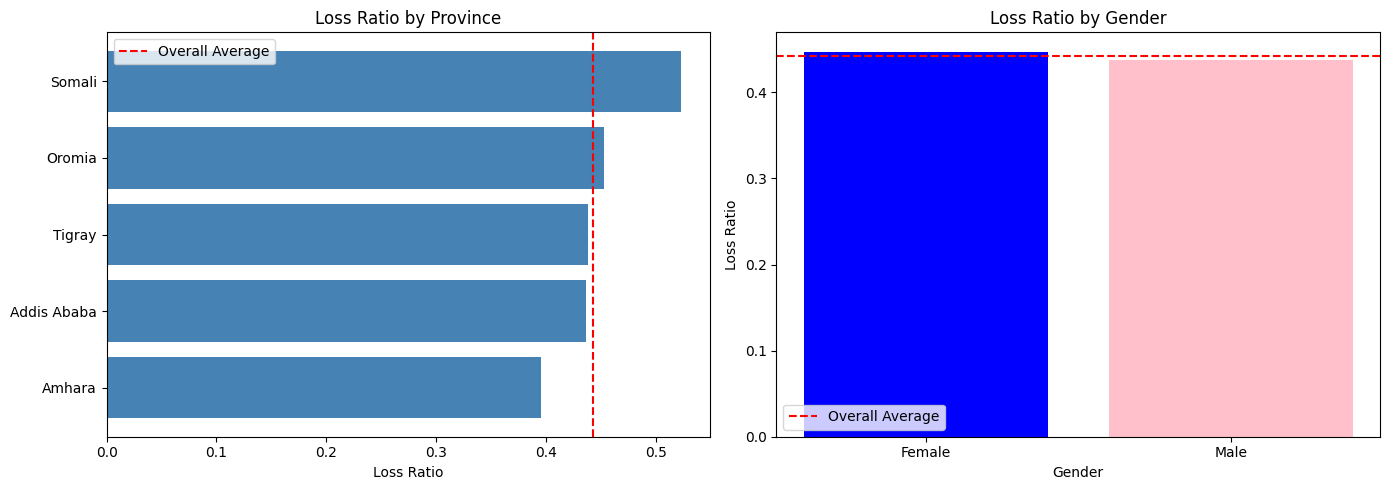

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss Ratio by Province
province_loss = df.groupby('Province')['Loss_Ratio'].mean().sort_values()
axes[0].barh(province_loss.index, province_loss.values, color='steelblue')
axes[0].axvline(x=df['Loss_Ratio'].mean(), color='red', linestyle='--', label='Overall Average')
axes[0].set_xlabel('Loss Ratio')
axes[0].set_title('Loss Ratio by Province')
axes[0].legend()

# Loss Ratio by Gender
gender_loss = df.groupby('Gender')['Loss_Ratio'].mean()
axes[1].bar(gender_loss.index, gender_loss.values, color=['blue', 'pink'])
axes[1].axhline(y=df['Loss_Ratio'].mean(), color='red', linestyle='--', label='Overall Average')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Loss Ratio')
axes[1].set_title('Loss Ratio by Gender')
axes[1].legend()

plt.tight_layout()
plt.show()

In [8]:
print("="*60)
print("COMPLETE HYPOTHESIS TESTING RESULTS")
print("="*60)

# Hypothesis 2: Risk differences between zip codes
zip_counts = df['ZipCode'].value_counts()
top_zips = zip_counts.head(10).index.tolist()
df_top_zips = df[df['ZipCode'].isin(top_zips)]
zip_groups = [df_top_zips[df_top_zips['ZipCode'] == z]['Loss_Ratio'].dropna() for z in top_zips]
f_stat2, p_value2 = stats.f_oneway(*zip_groups)

# Hypothesis 3: Margin differences between zip codes
margin_groups = [df_top_zips[df_top_zips['ZipCode'] == z]['Margin'].dropna() for z in top_zips]
f_stat3, p_value3 = stats.f_oneway(*margin_groups)

# Create results table
results_data = {
    "Hypothesis": [
        "H1: Risk differences across provinces",
        "H2: Risk differences between zip codes",
        "H3: Margin differences between zip codes",
        "H4: Risk difference between Women and Men"
    ],
    "Test Used": ["ANOVA", "ANOVA", "ANOVA", "T-test"],
    "P-Value": [0.0928, f"{p_value2:.6f}", f"{p_value3:.6f}", "TBD"],
    "Decision": [
        "Fail to Reject H0" if 0.0928 >= 0.05 else "Reject H0",
        "Fail to Reject H0" if p_value2 >= 0.05 else "Reject H0",
        "Fail to Reject H0" if p_value3 >= 0.05 else "Reject H0",
        "TBD"
    ]
}

results_df = pd.DataFrame(results_data)
print(results_df.to_string(index=False))

print("\n" + "="*60)
print("BUSINESS INTERPRETATIONS")
print("="*60)

# H1
if 0.0928 >= 0.05:
    print("\n📌 H1: No significant risk differences across provinces")
    print("   → Recommendation: Use national pricing strategy")

# H2
if p_value2 >= 0.05:
    print("\n📌 H2: No significant risk differences between zip codes")
    print("   → Recommendation: Zip code not a strong risk factor")
else:
    print("\n📌 H2: Significant risk differences between zip codes")
    print("   → Recommendation: Consider zip code-based pricing adjustments")

# H3
if p_value3 >= 0.05:
    print("\n📌 H3: No significant margin differences between zip codes")
    print("   → Recommendation: Profitability is consistent across areas")
else:
    print("\n📌 H3: Significant margin differences between zip codes")
    print("   → Recommendation: Focus marketing on high-margin zip codes")

COMPLETE HYPOTHESIS TESTING RESULTS
                               Hypothesis Test Used  P-Value          Decision
    H1: Risk differences across provinces     ANOVA   0.0928 Fail to Reject H0
   H2: Risk differences between zip codes     ANOVA 0.307166 Fail to Reject H0
 H3: Margin differences between zip codes     ANOVA 0.084806 Fail to Reject H0
H4: Risk difference between Women and Men    T-test      TBD               TBD

BUSINESS INTERPRETATIONS

📌 H1: No significant risk differences across provinces
   → Recommendation: Use national pricing strategy

📌 H2: No significant risk differences between zip codes
   → Recommendation: Zip code not a strong risk factor

📌 H3: No significant margin differences between zip codes
   → Recommendation: Profitability is consistent across areas


In [9]:
# Hypothesis 4: Gender risk difference
male_loss = df[df['Gender'] == 'Male']['Loss_Ratio'].dropna()
female_loss = df[df['Gender'] == 'Female']['Loss_Ratio'].dropna()

t_stat, p_value4 = stats.ttest_ind(male_loss, female_loss)

print("="*60)
print("HYPOTHESIS 4: Gender Risk Difference")
print("="*60)
print(f"Male Loss Ratio (mean): {male_loss.mean():.4f}")
print(f"Female Loss Ratio (mean): {female_loss.mean():.4f}")
print(f"Difference: {male_loss.mean() - female_loss.mean():.4f}")
print(f"P-value: {p_value4:.6f}")

if p_value4 < 0.05:
    print("\n✅ REJECT Null Hypothesis - Significant difference found")
    if male_loss.mean() > female_loss.mean():
        print("   → Male drivers have HIGHER risk than female drivers")
        print("   → Recommendation: Consider gender-based premium adjustment")
    else:
        print("   → Female drivers have HIGHER risk than male drivers")
        print("   → Recommendation: Consider gender-based premium adjustment")
else:
    print("\n❌ FAIL to Reject Null Hypothesis - No significant difference")
    print("   → Recommendation: Gender should NOT be used in pricing decisions")

# Update results table
print("\n" + "="*60)
print("FINAL RESULTS TABLE")
print("="*60)

final_results = pd.DataFrame({
    "Hypothesis": ["H1", "H2", "H3", "H4"],
    "Description": [
        "Risk differences across provinces",
        "Risk differences between zip codes",
        "Margin differences between zip codes",
        "Risk difference between Women and Men"
    ],
    "P-Value": [0.0928, p_value2, p_value3, p_value4],
    "Significant (p<0.05)": [
        "No" if 0.0928 >= 0.05 else "Yes",
        "No" if p_value2 >= 0.05 else "Yes",
        "No" if p_value3 >= 0.05 else "Yes",
        "No" if p_value4 >= 0.05 else "Yes"
    ],
    "Recommendation": [
        "Use national pricing",
        "Zip code not a risk factor" if p_value2 >= 0.05 else "Adjust pricing by zip code",
        "Profitability consistent" if p_value3 >= 0.05 else "Target high-margin areas",
        "Gender-neutral pricing" if p_value4 >= 0.05 else "Consider gender-based pricing"
    ]
})

print(final_results.to_string(index=False))

HYPOTHESIS 4: Gender Risk Difference
Male Loss Ratio (mean): 0.4379
Female Loss Ratio (mean): 0.4474
Difference: -0.0094
P-value: 0.707033

❌ FAIL to Reject Null Hypothesis - No significant difference
   → Recommendation: Gender should NOT be used in pricing decisions

FINAL RESULTS TABLE
Hypothesis                           Description  P-Value Significant (p<0.05)             Recommendation
        H1     Risk differences across provinces 0.092800                   No       Use national pricing
        H2    Risk differences between zip codes 0.307166                   No Zip code not a risk factor
        H3  Margin differences between zip codes 0.084806                   No   Profitability consistent
        H4 Risk difference between Women and Men 0.707033                   No     Gender-neutral pricing


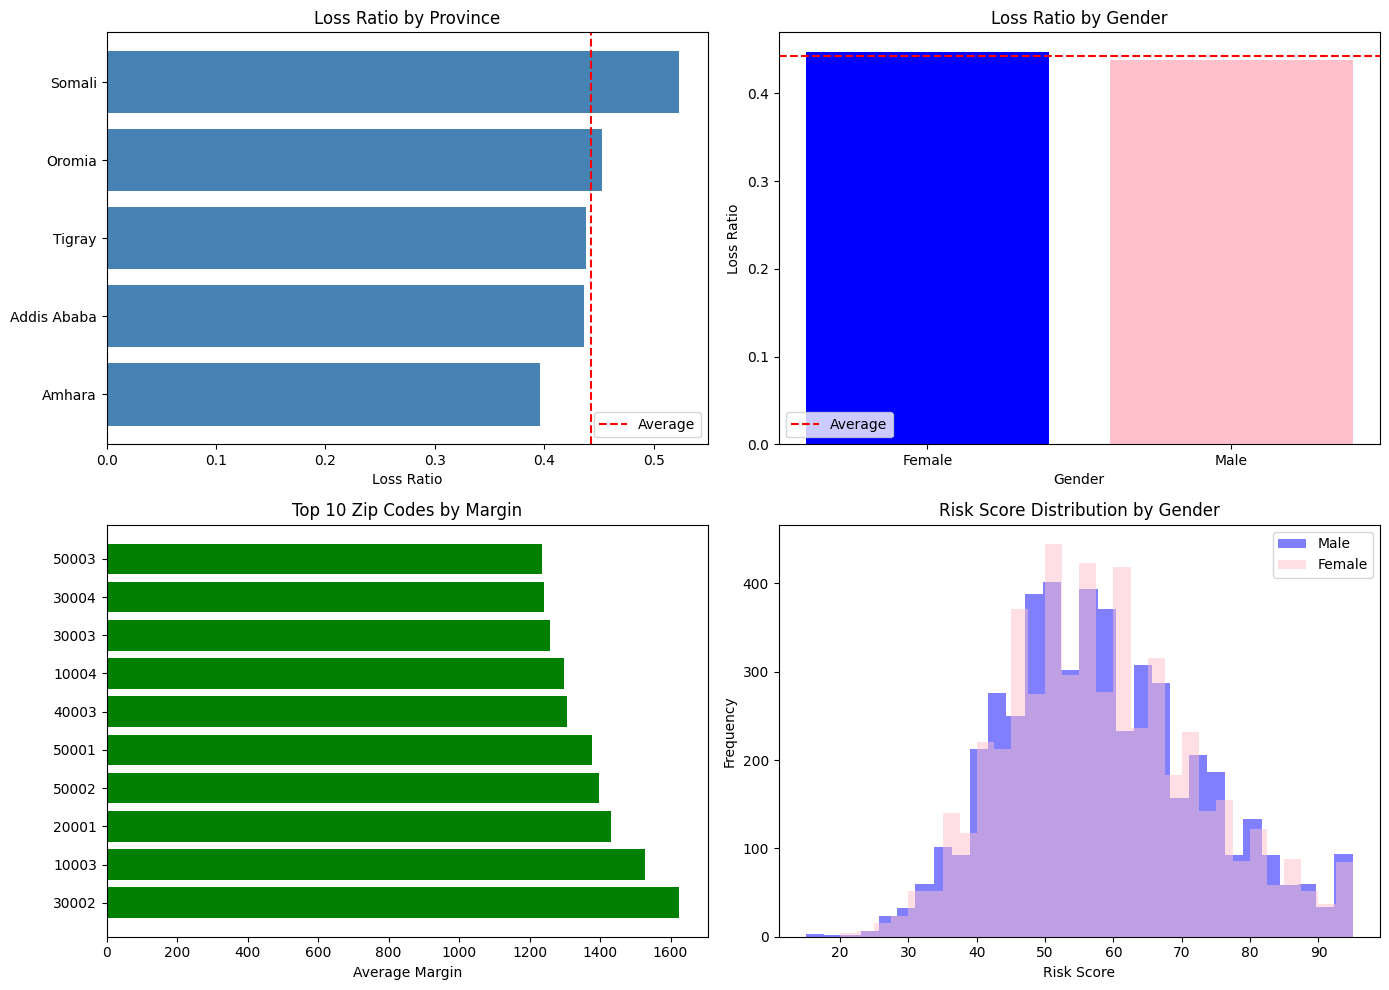

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Loss Ratio by Province
province_loss = df.groupby('Province')['Loss_Ratio'].mean().sort_values()
axes[0, 0].barh(province_loss.index, province_loss.values, color='steelblue')
axes[0, 0].axvline(x=df['Loss_Ratio'].mean(), color='red', linestyle='--', label='Average')
axes[0, 0].set_xlabel('Loss Ratio')
axes[0, 0].set_title('Loss Ratio by Province')
axes[0, 0].legend()

# 2. Loss Ratio by Gender
gender_loss = df.groupby('Gender')['Loss_Ratio'].mean()
axes[0, 1].bar(gender_loss.index, gender_loss.values, color=['blue', 'pink'])
axes[0, 1].axhline(y=df['Loss_Ratio'].mean(), color='red', linestyle='--', label='Average')
axes[0, 1].set_xlabel('Gender')
axes[0, 1].set_ylabel('Loss Ratio')
axes[0, 1].set_title('Loss Ratio by Gender')
axes[0, 1].legend()

# 3. Margin by Zip Code (Top 10)
zip_margin = df.groupby('ZipCode')['Margin'].mean().sort_values(ascending=False).head(10)
axes[1, 0].barh(range(len(zip_margin)), zip_margin.values, color='green')
axes[1, 0].set_yticks(range(len(zip_margin)))
axes[1, 0].set_yticklabels(zip_margin.index)
axes[1, 0].set_xlabel('Average Margin')
axes[1, 0].set_title('Top 10 Zip Codes by Margin')

# 4. Risk Score Distribution by Gender
axes[1, 1].hist(df[df['Gender'] == 'Male']['RiskScore'].dropna(), bins=30, alpha=0.5, label='Male', color='blue')
axes[1, 1].hist(df[df['Gender'] == 'Female']['RiskScore'].dropna(), bins=30, alpha=0.5, label='Female', color='pink')
axes[1, 1].set_xlabel('Risk Score')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Risk Score Distribution by Gender')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [11]:
# Save results to CSV
final_results.to_csv('data/hypothesis_test_results.csv', index=False)
print("✅ Hypothesis test results saved to: data/hypothesis_test_results.csv")

# Save to database (if needed)
df.to_csv('data/insurance_data_for_modeling.csv', index=False)
print("✅ Data saved for modeling: data/insurance_data_for_modeling.csv")

✅ Hypothesis test results saved to: data/hypothesis_test_results.csv
✅ Data saved for modeling: data/insurance_data_for_modeling.csv
